In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/input/vendas_2025.csv")
df_lojas = pd.read_csv("data/input/cadastro_lojas.csv")
df_produtos = pd.read_csv("data/input/cadastro_produtos.csv")

#### Aquecimento

In [3]:
display(df)

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto
0,1,2025-04-17,centro,Eduardo,Meia,Acessórios,2,19.9,0.20,Dinheiro
1,2,2025-04-10,centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix
3,4,2025-06-19,centro,Diego,NaN,Roupas,3,59.9,0.05,Dinheiro
4,5,2025-05-11,Centro,Carla,Meia,Acessórios,1,19.9,0.05,Dinheiro
...,...,...,...,...,...,...,...,...,...,...
1195,1196,2025-08-21,Bairro,Diego,Tênis,Calçados,3,249.9,0.10,Dinheiro
1196,1197,2025-05-02,Bairro,Carla,Boné,Acessórios,4,49.9,0.15,Dinheiro
1197,1198,2025-05-27,Shopping,Ana,Camiseta,Roupas,1,59.9,0.20,Pix
1198,1199,2025-05-24,Centro,Eduardo,Tênis,Calçados,4,249.9,0.00,Dinheiro


In [4]:
# 1. Exiba as 5 primeiras linhas do DataFrame `vendas`.
display(df.head())

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto
0,1,2025-04-17,centro,Eduardo,Meia,Acessórios,2,19.9,0.20,Dinheiro
1,2,2025-04-10,centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix
3,4,2025-06-19,centro,Diego,NaN,Roupas,3,59.9,0.05,Dinheiro
4,5,2025-05-11,Centro,Carla,Meia,Acessórios,1,19.9,0.05,Dinheiro


In [5]:
# 2. Exiba as 5 últimas linhas.
display(df.tail())

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto
1195,1196,2025-08-21,Bairro,Diego,Tênis,Calçados,3,249.9,0.10,Dinheiro
1196,1197,2025-05-02,Bairro,Carla,Boné,Acessórios,4,49.9,0.15,Dinheiro
1197,1198,2025-05-27,Shopping,Ana,Camiseta,Roupas,1,59.9,0.20,Pix
1198,1199,2025-05-24,Centro,Eduardo,Tênis,Calçados,4,249.9,0.00,Dinheiro
1199,1200,2025-06-10,Centro,Eduardo,Tênis,Calçados,1,249.9,0.05,Cartão


In [6]:
# 3. Verifique quantas linhas e colunas existem.
display(df.shape)

(1200, 10)

In [7]:
# 4. Liste o nome das colunas.
display(list(df.columns))

['id_venda',
 'data',
 'loja',
 'vendedor',
 'produto',
 'categoria',
 'qtd',
 'preco_unit',
 'desconto',
 'forma_pgto']

In [8]:
# 5. Verifique os tipos de dados.
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_venda    1200 non-null   int64  
 1   data        1200 non-null   object 
 2   loja        1200 non-null   object 
 3   vendedor    1200 non-null   object 
 4   produto     1162 non-null   object 
 5   categoria   1200 non-null   object 
 6   qtd         1200 non-null   int64  
 7   preco_unit  1200 non-null   float64
 8   desconto    1200 non-null   float64
 9   forma_pgto  1200 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 93.9+ KB


None

#### Exploração e inspeção

In [9]:
# 6. Utilize `describe()` para as colunas numéricas.
display(df.describe())

,id_venda,qtd,preco_unit,desconto
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,3.030833,98.875000,0.050958
std,346.554469,1.409446,80.969105,0.062251
min,1.000000,1.000000,19.900000,0.000000
25%,300.750000,2.000000,49.900000,0.000000
50%,600.500000,3.000000,59.900000,0.000000
75%,900.250000,4.000000,129.900000,0.100000
max,1200.000000,5.000000,249.900000,0.200000


In [10]:
# 7. Use `value_counts()` para:
# - vendas por loja
df["loja"].value_counts()

loja
Shopping    316
Bairro      302
Centro      299
centro      283
Name: count, dtype: int64

In [11]:
# - vendas por forma de pagamento
df["forma_pgto"].value_counts()

forma_pgto
Dinheiro    410
Cartão      399
Pix         391
Name: count, dtype: int64

In [12]:
# 8. Descubra:
# - maior preço unitário
df["preco_unit"].max()

np.float64(249.9)

In [13]:
# - quantidade total vendida
df["qtd"].sum()

np.int64(3637)

In [14]:
# 9. Verifique valores nulos por coluna.
df.isna().sum()

id_venda       0
data           0
loja           0
vendedor       0
produto       38
categoria      0
qtd            0
preco_unit     0
desconto       0
forma_pgto     0
dtype: int64

#### Limpeza e tratamento de dados

In [15]:
df_analise = df

In [16]:
# 10. Converta a coluna `data` para datetime.
df_analise['data'] = pd.to_datetime(df_analise["data"], format="%Y-%m-%d")

In [17]:
# 11. Padronize a coluna `loja` (remova espaços e padronize texto).
df_analise["loja"] = df_analise["loja"].str.strip().str.title()

In [18]:
# 12. Substitua valores nulos de `desconto` por 0.
df_analise["desconto"] = df_analise["desconto"].fillna(0)

In [19]:
# 13. Trate valores nulos da coluna `produto`.
df_analise["produto"] = df_analise["produto"].fillna("Não Informado")

#### Criação de métricas

In [20]:
# 14. Crie a coluna `preco_final`.
df_analise["preco_final"] = (df_analise["preco_unit"] * df_analise["qtd"]) - df_analise["desconto"]

In [21]:
# 15. Crie a coluna `faturamento`.
df_analise["faturamento"] = df_analise["preco_final"]

In [22]:
# 16. Crie a coluna `teve_desconto`.
df_analise["teve_desconto"] = (df_analise["desconto"] > 0).map({True: "Sim", False: "Não"})

In [23]:
# 17. Crie a coluna `ticket_medio_item`.
df_analise["ticket_medio_item"] = df_analise["preco_final"] / df_analise["qtd"]

#### Filtros e segmentações

In [24]:
# 18. Filtre vendas da loja Centro.
df_analise.loc[df_analise["loja"] == "Centro"]

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item
0,1,2025-04-17,Centro,Eduardo,Meia,Acessórios,2,19.9,0.20,Dinheiro,39.60,39.60,Sim,19.800000
1,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,499.80,499.80,Não,249.900000
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,649.50,649.50,Não,129.900000
3,4,2025-06-19,Centro,Diego,Não Informado,Roupas,3,59.9,0.05,Dinheiro,179.65,179.65,Sim,59.883333
4,5,2025-05-11,Centro,Carla,Meia,Acessórios,1,19.9,0.05,Dinheiro,19.85,19.85,Sim,19.850000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190,1191,2025-11-16,Centro,Eduardo,Meia,Acessórios,4,19.9,0.00,Pix,79.60,79.60,Não,19.900000
1192,1193,2025-10-01,Centro,Carla,Calça,Roupas,2,129.9,0.05,Dinheiro,259.75,259.75,Sim,129.875000
1194,1195,2025-12-12,Centro,Ana,Meia,Acessórios,3,19.9,0.00,Pix,59.70,59.70,Não,19.900000
1198,1199,2025-05-24,Centro,Eduardo,Tênis,Calçados,4,249.9,0.00,Dinheiro,999.60,999.60,Não,249.900000


In [25]:
# 19. Filtre vendas com faturamento maior que 200.
df_analise.loc[df_analise["faturamento"] > 200]

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item
1,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,499.80,499.80,Não,249.900000
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,649.50,649.50,Não,129.900000
5,6,2025-11-12,Shopping,Bruno,Calça,Roupas,2,129.9,0.15,Pix,259.65,259.65,Sim,129.825000
6,7,2025-09-21,Bairro,Carla,Calça,Roupas,4,129.9,0.05,Cartão,519.55,519.55,Sim,129.887500
9,10,2025-10-07,Shopping,Ana,Calça,Roupas,4,129.9,0.05,Pix,519.55,519.55,Sim,129.887500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,1193,2025-10-01,Centro,Carla,Calça,Roupas,2,129.9,0.05,Dinheiro,259.75,259.75,Sim,129.875000
1193,1194,2025-05-11,Bairro,Eduardo,Tênis,Calçados,1,249.9,0.00,Pix,249.90,249.90,Não,249.900000
1195,1196,2025-08-21,Bairro,Diego,Tênis,Calçados,3,249.9,0.10,Dinheiro,749.60,749.60,Sim,249.866667
1198,1199,2025-05-24,Centro,Eduardo,Tênis,Calçados,4,249.9,0.00,Dinheiro,999.60,999.60,Não,249.900000


In [26]:
# 20. Filtre vendas da categoria Roupas pagas no Pix.
df_analise.loc[(df_analise["categoria"] == "Roupas") & (df_analise["forma_pgto"] == "Pix")]

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,649.50,649.50,Não,129.900000
5,6,2025-11-12,Shopping,Bruno,Calça,Roupas,2,129.9,0.15,Pix,259.65,259.65,Sim,129.825000
9,10,2025-10-07,Shopping,Ana,Calça,Roupas,4,129.9,0.05,Pix,519.55,519.55,Sim,129.887500
31,32,2025-12-04,Shopping,Carla,Camiseta,Roupas,1,59.9,0.00,Pix,59.90,59.90,Não,59.900000
40,41,2025-01-13,Centro,Bruno,Calça,Roupas,4,129.9,0.10,Pix,519.50,519.50,Sim,129.875000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1170,1171,2025-08-22,Bairro,Ana,Camiseta,Roupas,3,59.9,0.05,Pix,179.65,179.65,Sim,59.883333
1173,1174,2025-09-04,Centro,Eduardo,Não Informado,Roupas,2,59.9,0.00,Pix,119.80,119.80,Não,59.900000
1180,1181,2025-06-03,Shopping,Bruno,Calça,Roupas,4,129.9,0.00,Pix,519.60,519.60,Não,129.900000
1188,1189,2025-02-26,Centro,Bruno,Calça,Roupas,5,129.9,0.00,Pix,649.50,649.50,Não,129.900000


In [27]:
# 21. Filtre vendas por intervalo de datas.
df_analise.loc[(df_analise["data"] >= "2025-03-01") & (df_analise["data"] <= "2025-06-30")]

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item
0,1,2025-04-17,Centro,Eduardo,Meia,Acessórios,2,19.9,0.20,Dinheiro,39.60,39.60,Sim,19.800000
1,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,499.80,499.80,Não,249.900000
3,4,2025-06-19,Centro,Diego,Não Informado,Roupas,3,59.9,0.05,Dinheiro,179.65,179.65,Sim,59.883333
4,5,2025-05-11,Centro,Carla,Meia,Acessórios,1,19.9,0.05,Dinheiro,19.85,19.85,Sim,19.850000
11,12,2025-06-12,Bairro,Ana,Tênis,Calçados,2,249.9,0.00,Dinheiro,499.80,499.80,Não,249.900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1193,1194,2025-05-11,Bairro,Eduardo,Tênis,Calçados,1,249.9,0.00,Pix,249.90,249.90,Não,249.900000
1196,1197,2025-05-02,Bairro,Carla,Boné,Acessórios,4,49.9,0.15,Dinheiro,199.45,199.45,Sim,49.862500
1197,1198,2025-05-27,Shopping,Ana,Camiseta,Roupas,1,59.9,0.20,Pix,59.70,59.70,Sim,59.700000
1198,1199,2025-05-24,Centro,Eduardo,Tênis,Calçados,4,249.9,0.00,Dinheiro,999.60,999.60,Não,249.900000


#### Groupby e estatísticas

In [28]:
# 22. Faturamento total por loja
df_analise.groupby("loja")["faturamento"].sum()

loja
Bairro       90592.10
Centro      172207.95
Shopping    100435.10
Name: faturamento, dtype: float64

In [29]:
# 23. Faturamento por vendedor.
df_analise.groupby("vendedor")["faturamento"].sum()

vendedor
Ana        72856.55
Bruno      72167.15
Carla      73470.30
Diego      74934.00
Eduardo    69807.15
Name: faturamento, dtype: float64

In [30]:
# 24. Quantidade total vendida por produto.
df_analise.groupby("produto")["qtd"].sum()

produto
Boné             720
Calça            698
Camiseta         733
Meia             694
Não Informado    117
Tênis            675
Name: qtd, dtype: int64

In [31]:
# 25. Ticket médio por loja.
df_analise.groupby("loja")["ticket_medio_item"].mean()

loja
Bairro       97.689581
Centro       97.883648
Shopping    101.746501
Name: ticket_medio_item, dtype: float64

In [ ]:
# 26. Tabela resumo por categoria.
df_analise.groupby("categoria")["faturamento"].sum()

categoria
Acessórios     51437.05
Calçados      173169.70
Roupas        138628.40
Name: faturamento, dtype: float64

#### Rankings

In [33]:
#27. Top 5 produtos mais vendidos.
df_analise.groupby("produto")["qtd"].sum().sort_values(ascending=False).head(5)

produto
Camiseta    733
Boné        720
Calça       698
Meia        694
Tênis       675
Name: qtd, dtype: int64

In [34]:
# 28. Top 3 lojas por faturamento.
df_analise.groupby("loja")["faturamento"].sum().sort_values(ascending=False).head(3)

loja
Centro      172207.95
Shopping    100435.10
Bairro       90592.10
Name: faturamento, dtype: float64

In [35]:
# 29. Ranking de vendedores.
df_analise.groupby("vendedor")["faturamento"].sum().sort_values(ascending=False)

vendedor
Diego      74934.00
Carla      73470.30
Ana        72856.55
Bruno      72167.15
Eduardo    69807.15
Name: faturamento, dtype: float64

#### Merge e análise de metas

In [36]:
# 30. Faça merge entre vendas e cadastro de lojas.
df_vendas_lojas = pd.merge(df_analise, df_lojas, on="loja", how="left")

In [37]:
# 31. Calcule faturamento por cidade e região.
df_vendas_lojas.groupby(["cidade", "regiao"], as_index=False)["faturamento"].sum()

,cidade,regiao,faturamento
0,Campinas,Sudeste,90592.10
1,São Paulo,Sudeste,272643.05


In [38]:
# 32. Compare faturamento real com a meta anual.
df_faturamento_total_lojas = df_vendas_lojas.groupby("loja", as_index=False)["faturamento"].sum()
display(df_faturamento_total_lojas)

,loja,faturamento
0,Bairro,90592.10
1,Centro,172207.95
2,Shopping,100435.10


In [39]:
df_comparacao_faturamento_meta = pd.merge(df_faturamento_total_lojas, df_lojas, on="loja", how="left")

In [40]:
df_comparacao_faturamento_meta["atingiu_meta"] = (df_comparacao_faturamento_meta["faturamento"] >= df_comparacao_faturamento_meta["meta_anual"]).map({True: "Sim", False: "Não"})
display(df_comparacao_faturamento_meta)

,loja,faturamento,cidade,regiao,meta_anual,atingiu_meta
0,Bairro,90592.10,Campinas,Sudeste,800000,Não
1,Centro,172207.95,São Paulo,Sudeste,1200000,Não
2,Shopping,100435.10,São Paulo,Sudeste,1000000,Não


#### Análise temporal

In [41]:
# 33. Crie colunas de mês e dia da semana.
df_vendas_lojas["mes"] = df_vendas_lojas["data"].dt.month
display(df_vendas_lojas)

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item,cidade,regiao,meta_anual,mes
0,1,2025-04-17,Centro,Eduardo,Meia,Acessórios,2,19.9,0.20,Dinheiro,39.60,39.60,Sim,19.800000,São Paulo,Sudeste,1200000,4
1,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,499.80,499.80,Não,249.900000,São Paulo,Sudeste,1200000,4
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,649.50,649.50,Não,129.900000,São Paulo,Sudeste,1200000,10
3,4,2025-06-19,Centro,Diego,Não Informado,Roupas,3,59.9,0.05,Dinheiro,179.65,179.65,Sim,59.883333,São Paulo,Sudeste,1200000,6
4,5,2025-05-11,Centro,Carla,Meia,Acessórios,1,19.9,0.05,Dinheiro,19.85,19.85,Sim,19.850000,São Paulo,Sudeste,1200000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,1196,2025-08-21,Bairro,Diego,Tênis,Calçados,3,249.9,0.10,Dinheiro,749.60,749.60,Sim,249.866667,Campinas,Sudeste,800000,8
1196,1197,2025-05-02,Bairro,Carla,Boné,Acessórios,4,49.9,0.15,Dinheiro,199.45,199.45,Sim,49.862500,Campinas,Sudeste,800000,5
1197,1198,2025-05-27,Shopping,Ana,Camiseta,Roupas,1,59.9,0.20,Pix,59.70,59.70,Sim,59.700000,São Paulo,Sudeste,1000000,5
1198,1199,2025-05-24,Centro,Eduardo,Tênis,Calçados,4,249.9,0.00,Dinheiro,999.60,999.60,Não,249.900000,São Paulo,Sudeste,1200000,5


In [42]:
df_vendas_lojas["dia"] = df_vendas_lojas["data"].dt.day_name()
display(df_vendas_lojas)

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item,cidade,regiao,meta_anual,mes,dia
0,1,2025-04-17,Centro,Eduardo,Meia,Acessórios,2,19.9,0.20,Dinheiro,39.60,39.60,Sim,19.800000,São Paulo,Sudeste,1200000,4,Thursday
1,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,499.80,499.80,Não,249.900000,São Paulo,Sudeste,1200000,4,Thursday
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,649.50,649.50,Não,129.900000,São Paulo,Sudeste,1200000,10,Saturday
3,4,2025-06-19,Centro,Diego,Não Informado,Roupas,3,59.9,0.05,Dinheiro,179.65,179.65,Sim,59.883333,São Paulo,Sudeste,1200000,6,Thursday
4,5,2025-05-11,Centro,Carla,Meia,Acessórios,1,19.9,0.05,Dinheiro,19.85,19.85,Sim,19.850000,São Paulo,Sudeste,1200000,5,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,1196,2025-08-21,Bairro,Diego,Tênis,Calçados,3,249.9,0.10,Dinheiro,749.60,749.60,Sim,249.866667,Campinas,Sudeste,800000,8,Thursday
1196,1197,2025-05-02,Bairro,Carla,Boné,Acessórios,4,49.9,0.15,Dinheiro,199.45,199.45,Sim,49.862500,Campinas,Sudeste,800000,5,Friday
1197,1198,2025-05-27,Shopping,Ana,Camiseta,Roupas,1,59.9,0.20,Pix,59.70,59.70,Sim,59.700000,São Paulo,Sudeste,1000000,5,Tuesday
1198,1199,2025-05-24,Centro,Eduardo,Tênis,Calçados,4,249.9,0.00,Dinheiro,999.60,999.60,Não,249.900000,São Paulo,Sudeste,1200000,5,Saturday


In [43]:
# 34. Faturamento mensal.
df_vendas_lojas.groupby("mes", as_index=False)["faturamento"].sum()

,mes,faturamento
0,1,28785.50
1,2,24537.25
2,3,24522.85
3,4,32796.35
4,5,33276.70
5,6,31893.55
6,7,32711.45
7,8,30892.85
8,9,29049.80
9,10,31613.65


In [44]:
# 35. Faturamento por dia da semana.
df_vendas_lojas.groupby("dia", as_index=False)["faturamento"].sum()

,dia,faturamento
0,Friday,54726.85
1,Monday,56306.85
2,Saturday,53774.10
3,Sunday,50010.35
4,Thursday,48170.00
5,Tuesday,46226.15
6,Wednesday,54020.85


In [45]:
# 36. Média móvel de 3 períodos.
df_vendas_lojas.sort_values("mes", inplace=True)
df_vendas_lojas["media_movel_3"] = df_vendas_lojas["faturamento"].rolling(window=3).mean()
display(df_vendas_lojas)

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item,cidade,regiao,meta_anual,mes,dia,media_movel_3
33,34,2025-01-22,Shopping,Eduardo,Camiseta,Roupas,3,59.9,0.05,Dinheiro,179.65,179.65,Sim,59.883333,São Paulo,Sudeste,1000000,1,Wednesday,NaN
40,41,2025-01-13,Centro,Bruno,Calça,Roupas,4,129.9,0.10,Pix,519.50,519.50,Sim,129.875000,São Paulo,Sudeste,1200000,1,Monday,NaN
1149,1150,2025-01-26,Shopping,Diego,Boné,Acessórios,3,49.9,0.10,Pix,149.60,149.60,Sim,49.866667,São Paulo,Sudeste,1000000,1,Sunday,282.916667
1125,1126,2025-01-09,Centro,Diego,Tênis,Calçados,4,249.9,0.15,Pix,999.45,999.45,Sim,249.862500,São Paulo,Sudeste,1200000,1,Thursday,556.183333
374,375,2025-01-28,Bairro,Diego,Camiseta,Roupas,5,59.9,0.05,Cartão,299.45,299.45,Sim,59.890000,Campinas,Sudeste,800000,1,Tuesday,482.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128,1129,2025-12-31,Centro,Carla,Meia,Acessórios,2,19.9,0.05,Cartão,39.75,39.75,Sim,19.875000,São Paulo,Sudeste,1200000,12,Wednesday,119.766667
414,415,2025-12-15,Shopping,Bruno,Camiseta,Roupas,1,59.9,0.00,Dinheiro,59.90,59.90,Não,59.900000,São Paulo,Sudeste,1000000,12,Monday,53.183333
1194,1195,2025-12-12,Centro,Ana,Meia,Acessórios,3,19.9,0.00,Pix,59.70,59.70,Não,19.900000,São Paulo,Sudeste,1200000,12,Friday,53.116667
413,414,2025-12-20,Bairro,Carla,Calça,Roupas,1,129.9,0.00,Dinheiro,129.90,129.90,Não,129.900000,Campinas,Sudeste,800000,12,Saturday,83.166667


#### Gráficos

<Axes: title={'center': 'Faturamento Mensal'}, xlabel='Mês', ylabel='Faturamento'>

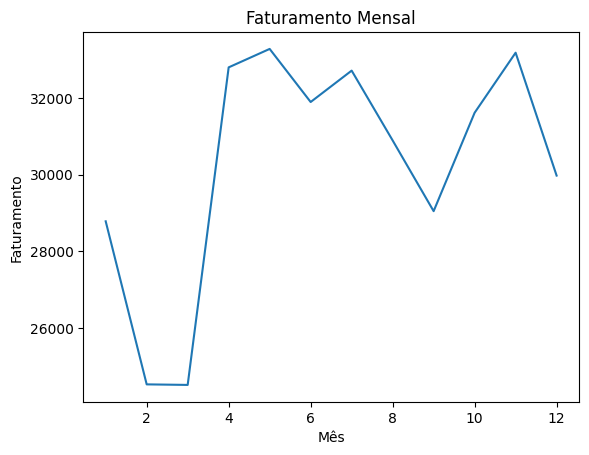

In [46]:
# 37. Gráfico de linha do faturamento mensal.
df_vendas_lojas.groupby("mes")["faturamento"].sum().sort_index().plot(kind="line", title="Faturamento Mensal", xlabel="Mês", ylabel="Faturamento")

<Axes: title={'center': 'Faturamento por Loja'}, xlabel='loja', ylabel='Faturamento'>

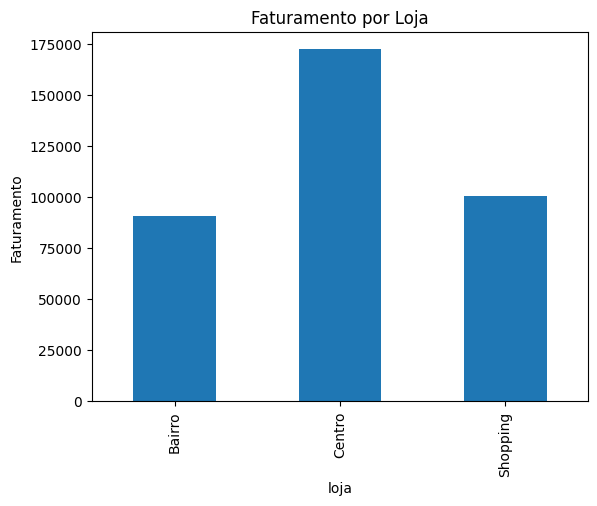

In [47]:
# 38. Gráfico de barras do faturamento por loja.
df_vendas_lojas.groupby("loja")["faturamento"].sum().sort_index().plot(kind="bar", title="Faturamento por Loja", xlabel="loja", ylabel="Faturamento")

<Axes: title={'center': 'Quantidade de produtos vendidos'}, xlabel='Produtos', ylabel='Quantidade de vendas'>

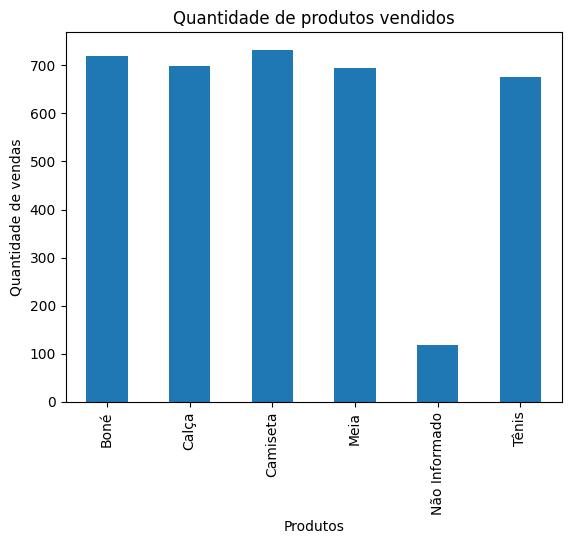

In [48]:
# 39. Gráfico dos produtos mais vendidos.
df_vendas_lojas.groupby("produto")["qtd"].sum().sort_index().plot(kind="bar", title="Quantidade de produtos vendidos", xlabel="Produtos", ylabel="Quantidade de vendas")

## Desafio Final

In [49]:
df_vendas_lojas

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item,cidade,regiao,meta_anual,mes,dia,media_movel_3
33,34,2025-01-22,Shopping,Eduardo,Camiseta,Roupas,3,59.9,0.05,Dinheiro,179.65,179.65,Sim,59.883333,São Paulo,Sudeste,1000000,1,Wednesday,NaN
40,41,2025-01-13,Centro,Bruno,Calça,Roupas,4,129.9,0.10,Pix,519.50,519.50,Sim,129.875000,São Paulo,Sudeste,1200000,1,Monday,NaN
1149,1150,2025-01-26,Shopping,Diego,Boné,Acessórios,3,49.9,0.10,Pix,149.60,149.60,Sim,49.866667,São Paulo,Sudeste,1000000,1,Sunday,282.916667
1125,1126,2025-01-09,Centro,Diego,Tênis,Calçados,4,249.9,0.15,Pix,999.45,999.45,Sim,249.862500,São Paulo,Sudeste,1200000,1,Thursday,556.183333
374,375,2025-01-28,Bairro,Diego,Camiseta,Roupas,5,59.9,0.05,Cartão,299.45,299.45,Sim,59.890000,Campinas,Sudeste,800000,1,Tuesday,482.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128,1129,2025-12-31,Centro,Carla,Meia,Acessórios,2,19.9,0.05,Cartão,39.75,39.75,Sim,19.875000,São Paulo,Sudeste,1200000,12,Wednesday,119.766667
414,415,2025-12-15,Shopping,Bruno,Camiseta,Roupas,1,59.9,0.00,Dinheiro,59.90,59.90,Não,59.900000,São Paulo,Sudeste,1000000,12,Monday,53.183333
1194,1195,2025-12-12,Centro,Ana,Meia,Acessórios,3,19.9,0.00,Pix,59.70,59.70,Não,19.900000,São Paulo,Sudeste,1200000,12,Friday,53.116667
413,414,2025-12-20,Bairro,Carla,Calça,Roupas,1,129.9,0.00,Dinheiro,129.90,129.90,Não,129.900000,Campinas,Sudeste,800000,12,Saturday,83.166667


In [50]:
# Faturamento total do ano
df_vendas_lojas["faturamento"].sum()

np.float64(363235.15)

In [51]:
# Top 3 lojas
df_vendas_lojas.groupby("loja", as_index=False)["qtd"].sum().sort_values(by="qtd", ascending=False)

,loja,qtd
1,Centro,1727
2,Shopping,992
0,Bairro,918


In [52]:
# Top 5 produtos
df_vendas_lojas.groupby("produto")["qtd"].sum().sort_values(ascending=False).head(5)

produto
Camiseta    733
Boné        720
Calça       698
Meia        694
Tênis       675
Name: qtd, dtype: int64

In [53]:
# Melhor vendedor
df_vendas_lojas.groupby("vendedor")["faturamento"].sum().sort_values(ascending=False).head(1)

vendedor
Diego    74934.0
Name: faturamento, dtype: float64

In [54]:
# Comparação Pix vs Cartão
df_vendas_lojas.groupby("forma_pgto")["qtd"].sum().sort_values(ascending=False)

forma_pgto
Dinheiro    1245
Cartão      1225
Pix         1167
Name: qtd, dtype: int64

## Conclusão com sugestões de melhoria

Ao meu ver até agora, não vejo nada por enquanto que precisa ser melhorado, os desafios foram bem tranquilos de fazer e fáceis de entender as própostas.